In [ ]:
# 1. CARGA Y LIMPIEZA BÁSICA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PooledOLS
import warnings
warnings.filterwarnings("ignore")



df = pd.read_csv('../../data/panel_eps.csv')

df = df.rename(columns={"year": "año encuesta", "time": "ronda"})
df["año encuesta"] = 2000 + df["año encuesta"].astype(int)

df["edad_num"] = pd.to_numeric(df["edad"], errors="coerce")
df["año nacimiento"] = np.where(
    df["edad_num"] > 1900,                    
    df["edad_num"],
    df["año encuesta"] - df["edad_num"]
)

col = df.pop("año nacimiento")
df.insert(df.columns.get_loc("edad") + 1, "año nacimiento", col)


df["edad"] = np.where(
    df["edad_num"] > 1900,
    df["año encuesta"] - df["edad_num"],
    df["edad_num"]
).astype(float)          

df.drop(columns=["edad_num"], inplace=True)


# 2. TRATAMIENTO DE NULOS 

if "size" in df.columns and df["size"].isna().mean() > .7:
    df.drop(columns=["size"], inplace=True)

cat_vars = ["informal", "occupation", "selfemp",
            "publicemp", "sistema"]
for c in cat_vars:
    df[c] = (df[c]
             .astype("category")
             .cat.add_categories("missing")
             .fillna("missing"))

num_vars = ["wage", "hours", "expectancy", "edu",
            "exp", "children", "assets", "exp_sist"]
for c in num_vars:
    df[f"{c}_miss"] = df[c].isna().astype(int)
    df[c] = df[c].fillna(df[c].median())

other_cats = ["hombre", "region", "status", "cotizando",
              "illness", "cronica", "nocronica", "mental"]
for c in other_cats:
    df[c] = (df[c]
             .astype("category")
             .cat.add_categories("missing")
             .fillna("missing"))





1.Respuesta
-limpieza de datos y renombre de columnas para mejor entendimiento.

-se generalizó la columna edad y ahora muestra la edad del individuo al momento de realiazar la encuesta

-se creó una nueva columna con año de nacimiento el cual muestra el año de nacimiento del individuo

-la colmna year se cambio por año encuesta y ahora muesta enves de 12 mostará 2012

-time se renobmró por ronda 

-se creo una tabla comparativa de porcentaje de NaN por columna para ver si es necesario eliminar dicha columna

-se eliminaron las columnas fondoa, fondob,fondoc, fondod, fondoe debido a no tener valores.

-se considerará como columna candidata a eliminar 'size' debido al importante numero de NaNs 

In [ ]:
#analizar tablas con nulos
null_table = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Proporción (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Tipo': df.dtypes
})
null_table = null_table[null_table['Nulos'] > 0] \
             .sort_values(by='Proporción (%)', ascending=False)
print("\n=== Nulos y proporciones ===")
print(null_table)

unique_counts = df.nunique().sort_values()
print("\n=== Valores únicos por columna ===")
print(unique_counts)



=== Nulos y proporciones ===
        Nulos  Proporción (%)     Tipo
fondoa  96846           100.0  float64
fondob  96846           100.0  float64
fondoc  96846           100.0  float64
fondod  96846           100.0  float64
fondoe  96846           100.0  float64

=== Valores únicos por columna ===
fondoa                 0
fondob                 0
fondoc                 0
fondod                 0
fondoe                 0
exp_sist_miss          1
kids                   2
hours_miss             2
expectancy_miss        2
edu_miss               2
exp_miss               2
children_miss          2
wage_miss              2
assets_miss            2
mental                 3
nocronica              3
cotizando              3
cronica                3
illness                3
sistema                3
selfemp                3
informal               3
hombre                 3
publicemp              3
lmp                    3
situation              4
status                 6
ronda                  6


2. Respuesta:

Referencia: educación, edad, salario, horas, activos, dummies laborales/salud, niños y dummies de año (base = 2002).

R-cuadrado = 0,26.  el modelo explica un cuarto de la variación.

Resultado de coeficientes:

edu: –0,93.  año de estudio baja la expectativa. Gente más educada parte a trabajar más tarde lleva cotizar menos.

edad: +0,12	Cada año de edad sube la expectativa 0,12 años (los mayores ya han cotizado más).

log_assets:	–0,41	Más activos (log) → menor expectativa; indica que quienes tienen plata prefieren retirar antes que alargar la pensión.

kids: –4,66 Tener hijos baja fuerte la expectativa: más bocas que financiar.

cronica: +5,67	Declarar enfermedad crónica sube la expectativa. Puede deberse a sesgos en la entrevisa o beneficios especiales. 

mental:	–9,18 Problemas de salud mental recortan mucho la expectativa.

Año 2009: 262 La espectativa de vida se disparó frente a 2002. Probablemente algun cambio nacional o el fin de una crisis financiera.


Var no significativas

Salario (wage) y horas semanales: parecen no influir.

Ser informal o independiente tampoco cambia mucho la expectativa, dado el resto de controles.



In [ ]:
# 3. Construir modelo

binary_cols = ["hombre", "kids", "informal", "selfemp",
               "publicemp", "sistema", "cotizando",
               "illness", "cronica", "nocronica", "mental"]

for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

df["log_assets"] = np.log1p(df["assets"])
yr_dummies = pd.get_dummies(df["año encuesta"],
                            prefix="yr", drop_first=True)

continuous = ["edu", "edad", "wage", "hours", "log_assets"]
X = pd.concat([df[continuous + binary_cols], yr_dummies], axis=1)
X = sm.add_constant(X)

y = df["expectancy"]


df = df.set_index(["folio_n20", "ronda"]).sort_index()
X.index = df.index             
y.index = df.index

# 4.  POOLED OLS 
model = PooledOLS(y, X, check_rank=False)
res   = model.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             expectancy   R-squared:                        0.2581
Estimator:                  PooledOLS   R-squared (Between):              0.2103
No. Observations:               96846   R-squared (Within):               0.2871
Date:                Mon, May 19 2025   R-squared (Overall):              0.2581
Time:                        21:55:29   Log-likelihood                -6.291e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1603.8
Entities:                       33483   P-value                           0.0000
Avg Obs:                       2.8924   Distribution:                F(21,96824)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             377.41
                            

Respuesta 3:

edu: -0,14 no resulta estadísticamente significativo. Una vez que se controla la heterogeneidad individual, la educación deja de explicar diferencias en la expectativa.

Edad: sigue siendo el factor con mayor impacto positivo dentro de cada individuo; un año adicional eleva la expectativa en torno a 0,65 años, reflejando cotizaciones adicionales.

Situación laboral: Permanecer en un empleo informal: +8,1 y uno autónomo +5,8.  eleva la expectativa relativa al empleo formal privado.

Cambiarse al sistema público +10,0 muestra también un incremento sustancial en la expectativa.

Salario y horas: Un aumento del salario en niveles reduce levemente la expectativa (coeficiente negativo y pequeño).

Más horas trabajadas están asociadas a mayores expectativas: +0,82, coherente con mayores cotizaciones.

Salud: Declarar una enfermedad crónica eleva la expectativa (+8,0), posiblemente por beneficios previsionales; en cambio, declarar un problema de salud mental la reduce en torno a 6,7 años.

Dummies de año: los coeficientes positivos y crecientes sugieren que a partir de 2004 y sobre todo en 2009 hubo cambios importantes que auentaron la expectativa. 

La mayor parte de la variación explanada proviene de cambios de edad, sector laboral, condiciones de salud y shocks de año. La educación, al no variar dentro de una misma persona, pierde significancia estadística

In [ ]:
#5. Modelos aleatorio
from linearmodels.panel import PanelOLS


time_vars = ["edu", "edad", "wage", "hours", "log_assets"] + binary_cols

yr_dummies = pd.get_dummies(df["año encuesta"], prefix="yr", drop_first=True)
yr_dummies.index = df.index

X_fe = pd.concat([df[time_vars], yr_dummies], axis=1)

X_fe = X_fe.loc[:, X_fe.nunique() > 1]

y = df["expectancy"]
y.index = df.index

fe_mod = PanelOLS(y, X_fe, entity_effects=False)
fe_res = fe_mod.fit(cov_type="clustered", cluster_entity=True)
print(fe_res.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.4649
Estimator:                   PanelOLS   R-squared (Between):              0.7414
No. Observations:               96846   R-squared (Within):               0.2845
Date:                Mon, May 19 2025   R-squared (Overall):              0.4649
Time:                        21:55:31   Log-likelihood                -6.295e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4005.4
Entities:                       33483   P-value                           0.0000
Avg Obs:                       2.8924   Distribution:                F(21,96825)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):          5.224e+04
                            

Respuesta 4:

Edu: –0,14 (p-value 0,18). No significativo aquí, aunque mantiene signo negativo.

Edad: 0,65 por año (p < 0,01).

Horas: 0,82 por hora extra (p < 0,01).

Salario: –5 ×10⁻⁶ por unidad de ingreso (p < 0,01).

Log_assets: 0,14 (p = 0,22), no significativo.

Sector informal: 8,1 (p < 0,01); autónomo: +5,8 (p < 0,01); sistema público: +10,0 (p < 0,01).

Enfermedad crónica: 8,0 (p < 0,01); salud mental: –6,7 (p < 0,05).

Año 2009: 278 años (p < 0,01), sigue relejando una posible reforma importante.

Interpretación

El efecto negativo de la educación no resiste en RE (se vuelve no significativo), lo que sugiere que la heterogeneidad individual sesgaba parcialmente el pooled OLS.

La experiencia (edad) y la intensidad de cotización (horas) son los principales motores de la expectativa.

Cambios de sector y condiciones de salud tienen impactos relevantes: pasar al informal o autónomo y declarar enfermedad crónica elevan la expectativa, mientras que un problema mental la reduce.

Las dummies de año capturan shocks institucionales, con un pico notable en 2009.

In [ ]:
#6. Random Effects para el Ítem 4
import statsmodels.api as sm
from linearmodels.panel import RandomEffects


continuous = ["edu", "edad", "wage", "hours", "log_assets"]
X_re = pd.concat([df[continuous + binary_cols], yr_dummies], axis=1)

X_re  = sm.add_constant(X_re)
X_re  = X_re.loc[:, X_re.nunique() > 1]

X_re.index = df.index
y = df["expectancy"]
y.index = df.index

re_mod = RandomEffects(y, X_re)
re_res = re_mod.fit(cov_type="clustered", cluster_entity=True)

print(re_res.summary)


                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4649
Estimator:              RandomEffects   R-squared (Between):              0.7414
No. Observations:               96846   R-squared (Within):               0.2845
Date:                Mon, May 19 2025   R-squared (Overall):              0.4649
Time:                        21:55:33   Log-likelihood                -6.295e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4005.4
Entities:                       33483   P-value                           0.0000
Avg Obs:                       2.8924   Distribution:                F(21,96825)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):          5.224e+04
                            

Respuesta 5:
Pooled OLS mezcla variación entre y dentro de individuos, sin controlar heterogeneidad que no se observe.


Efectos Fijos (“within”) comparan a cada persona solo con sus propios cambios en el tiempo, eliminando todo lo que no varía (como edu).

Resultado: edu desaparece (constante), y variables como horas y sector informal cambian de signo/magnitud porque ahora reflejan dinámicas internas, no diferencias de un individuo a otro.

Random Effects mantiene ambas fuentes de variación pero supone que los efectos individuales no están correlacionados con los regresores.

Aquí edu reaparece pero pierde significancia, pues parte de su “poder explicativo” provenía de heterogeneidad fija que RE ahora asume irrelevante.

Variables robustas:

Independientemente de la especificación:

Edad: siempre positiva y altamente significativa.

Cronica: efecto positivo consistente.

Mental: efecto negativo consistente.

Shock 2009: dummy de año con un pico muy fuerte en todos los modelos.

Por eso, el mejor compromiso es un Correlated Random Effects, que:

Incluye edu (como RE),

Controla la heterogeneidad correlacionada (como FE).


Respuesta 6:

Se estimó un Random Effects que, además de los niveles habituales, incorpora para cada variable que cambia en el tiempo su promedio individual (“_mean”), de modo que el componente no observado puede correlacionarse con los regresores.

Recupera edu (año de educación) sin asumirse exógeno, al mismo tiempo que controla heterogeneidad correlacionada.

Descompone el efecto de cada variable en su componente intra (nivel) y entre (media), revelando dónde radica la relación con la expectativa.

Es adecuado para un panel corto (T = 6) con importante heterogeneidad individual, pues evita ni “invisibilizar” edu (como FE) ni sobre-confiar en la exogeneidad (como RE puro).

el modelo CRE parece modelar la parte no observada del individuo y estimar el verdadero impacto de los años de educación sobre la expectativa de pensión, diferenciando entre cambios personales y diferencias promedio entre personas.

In [ ]:
from linearmodels.panel import RandomEffects
import statsmodels.api as sm
#7. Modelo CRE

const_vars  = ["edu", "hombre"]
dyn_vars    = ["edad", "wage", "hours", "log_assets"] + [
    "kids", "informal", "selfemp", "publicemp",
    "sistema", "cotizando",
    "illness", "cronica", "nocronica", "mental"
]


means = (df[dyn_vars]
         .groupby(level=0)
         .transform("mean")
         .add_suffix("_mean"))


yr_dummies        = pd.get_dummies(df["año encuesta"], prefix="yr", drop_first=True)
yr_dummies.index  = df.index

X_cre = pd.concat([df[const_vars + dyn_vars], means, yr_dummies], axis=1)
X_cre = sm.add_constant(X_cre)

X_cre = X_cre.loc[:, X_cre.nunique() > 1]


y = df["expectancy"]
cre_mod = RandomEffects(y, X_cre, check_rank=False)
cre_res = cre_mod.fit(cov_type="clustered", cluster_entity=True)

print(cre_res.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.2554
Estimator:              RandomEffects   R-squared (Between):              0.1899
No. Observations:               96846   R-squared (Within):               0.2871
Date:                Mon, May 19 2025   R-squared (Overall):              0.2554
Time:                        21:55:37   Log-likelihood                -6.293e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      976.43
Entities:                       33483   P-value                           0.0000
Avg Obs:                       2.8924   Distribution:                F(34,96811)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             7601.7
                            

Respusta 7:

La mayoría de los alpha se agrupan cerca de 0, lo que indica que para la gran mayoría de las personas la esperanza de vida está bien explicada por las covariables incluidas en el modelo.

Valores negativos (alpha < 0): individuos cuya vida media es inferior a la predicha por las variables observadas (podrian ser factores de riesgo o desventajas no capturados).

Valores positivos (alpha > 0): individuos con vida media superior a lo esperado (podrian ser ventajas genéticas, estilo de vida saludable, mejor acceso a servicios).

hay variación permanente entre individuos en su expectativa de vida que no se captura con las variables observables.

la heterogeneidad no observada en la esperanza de vida es relevante y debe ser controlada o analizada explícitamente

In [7]:
alpha_hat = cre_res.resids.groupby(level=0).mean()
alpha_hat.describe()


count    33483.000000
mean         2.644998
std         63.972302
min       -175.467105
25%        -40.595197
50%         -0.801018
75%         10.893920
max        366.084923
Name: residual, dtype: float64

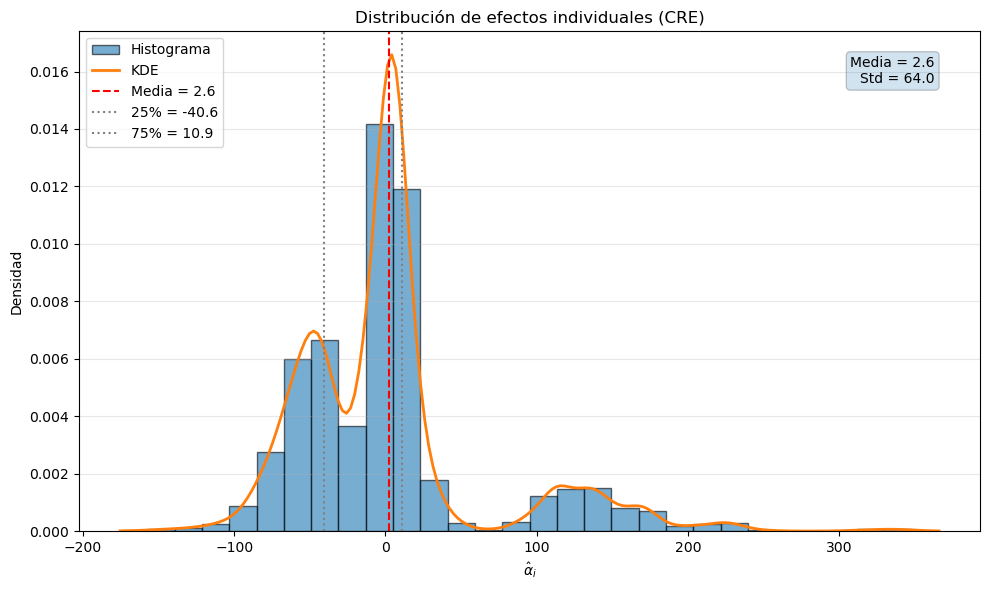

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

data = alpha_hat.values

plt.figure(figsize=(10, 6))
plt.grid(axis='y', alpha=0.3)

counts, bins, _ = plt.hist(data, bins=30, density=True,
                           edgecolor='black', alpha=0.6,
                           label='Histograma')
kde = gaussian_kde(data)
x_vals = np.linspace(bins.min(), bins.max(), 200)
plt.plot(x_vals, kde(x_vals), lw=2, label='KDE')

mean = data.mean()
std = data.std()
q1, q3 = np.percentile(data, [25, 75])
plt.axvline(mean, color='red', linestyle='--', label=f'Media = {mean:.1f}')
plt.axvline(q1, color='gray', linestyle=':', label=f'25% = {q1:.1f}')
plt.axvline(q3, color='gray', linestyle=':', label=f'75% = {q3:.1f}')

plt.text(0.95, 0.95,
         f'Media = {mean:.1f}\nStd = {std:.1f}',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.3', alpha=0.2))

plt.xlabel(r'$\hat\alpha_i$')
plt.ylabel('Densidad')
plt.title('Distribución de efectos individuales (CRE)')
plt.legend()
plt.tight_layout()
plt.show()


Respuesta 8:

Variables demográficas y de esfuerzo (edad, horas) son las que más desplazan la expectativa dentro de cada individuo.

Condiciones estructurales (riqueza, salud, tipo de ocupación, número de hijos) explican la mayor parte de las diferencias entre personas.

Shocks institucionales (reforma 2009) dominan, recordándonos que la política pública puede mover la expectativa de vida de pensión mucho más que los factores individuales.

La educación mantiene un efecto negativo (aunque moderado) una vez que se controla adecuadamente la heterogeneidad: empezar a cotizar tarde pesa más que los mayores salarios asociados.

En conjunto, el CRE muestra que tanto las trayectorias de cada persona como sus rasgos permanentes importan, y que los cambios de política pueden redefinir la expectativa de vida más que cualquier característica individual.

Rspuesta 9:

Promedio de educación de la cohorte-región (excluyéndose a sí mismo): refleja condiciones locales de oferta educativa sin depender directamente de la salud individual.

Exposición a la reforma escolar (Ley 19.532, cohortes nacidas desde 1990): un cambio legal que elevó la obligatoriedad a 12 años, exógeno respecto a la salud futura del individuo.

Resultados
Modelo agrupado (pooled IV-2SLS): los instrumentos son relevantes (F > 700), pero el coeficiente de educación es negativo (–5,6 años por año extra de estudio), lo cual contradice la intuición y resultados previos (OLS).

Modelo de panel con efectos fijos: tras eliminar efectos constantes de individuo y año, el efecto negativo se amplifica (–44 años por año de estudio). Aunque los instrumentos siguen siendo estadísticamente fuertes, el test de sobreidentificación (Hansen J) se rechaza, indicando violación de exogeneidad.

Conclusión
Aunque los instrumentos son relevantes, los resultados no son creíbles como efecto causal promedio. La magnitud y el signo sugieren que al menos uno de los instrumentos está correlacionado con factores no observados que también afectan la salud.

In [ ]:

import numpy as np
import pandas as pd
from linearmodels.iv import IV2SLS


grp = df.groupby(["region", "año nacimiento"])['edu']
grp_sum   = grp.transform('sum')
grp_count = grp.transform('count')

df['reg_cohort_mean_edu'] = np.where(
    grp_count > 1,
    (grp_sum - df['edu']) / (grp_count - 1),
    grp_sum / grp_count
)

df['post_reform_12yrs'] = (df['año nacimiento'] >= 1990).astype(int)



df_pool = df.reset_index()            
clusters_pool = df_pool['folio_n20']    

formula_pooled = (
    'expectancy ~ 1 + edad + wage + hours + log_assets '
    '+ [edu ~ reg_cohort_mean_edu + post_reform_12yrs]'
)

iv_pool = IV2SLS.from_formula(
    formula_pooled,
    data=df_pool
).fit(
    cov_type='clustered',
    clusters=clusters_pool
)

print("\n=== IV‑2SLS POOL ===")
print(iv_pool.summary)



if not isinstance(df.index, pd.MultiIndex):
    if {'folio_n20', 'ronda'}.issubset(df.columns):
        df = df.set_index(['folio_n20', 'ronda']).sort_index()
    else:
        raise ValueError("Se requiere MultiIndex (folio_n20, ronda).")

entity = df.index.get_level_values(0)
time   = df.index.get_level_values(1)

def double_demean(series):
    """Resta media por entidad y media por tiempo y suma media global."""
    return (series
            - series.groupby(entity).transform('mean')
            - series.groupby(time).transform('mean')
            + series.mean())

vars_y   = ['expectancy']
vars_exo = ['edad', 'wage', 'hours', 'log_assets']
vars_end = ['edu']
vars_iv  = ['reg_cohort_mean_edu', 'post_reform_12yrs']

for v in vars_y + vars_exo + vars_end + vars_iv:
    df[v + '_dd'] = double_demean(df[v])

Y      = df['expectancy_dd']
X_exog = df[[c + '_dd' for c in vars_exo]]
X_end  = df['edu_dd']
Z_iv   = df[[c + '_dd' for c in vars_iv]]

iv_panel = IV2SLS(
    dependent=Y,
    exog=X_exog,
    endog=X_end,
    instruments=Z_iv
).fit(
    cov_type='clustered',
    clusters=entity
)

print("=== IV-2SLS PANEL FE (double‑demeaned) ===")
print(iv_panel.summary)

print("--- Primera etapa (F-stat) ---")
print(iv_panel.first_stage.summary)

print("--- Sobre-identificación (Hansen J) ---")
print(iv_panel.sargan)



=== IV‑2SLS POOL ===
                          IV-2SLS Estimation Summary                          
Dep. Variable:             expectancy   R-squared:                     -0.0020
Estimator:                    IV-2SLS   Adj. R-squared:                -0.0021
No. Observations:               96846   F-statistic:                    723.80
Date:                Mon, May 19 2025   P-value (F-stat)                0.0000
Time:                        21:55:39   Distribution:                  chi2(5)
Cov. Estimator:             clustered                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      185.55     5.0913     36.446     0.0000      175.58      195.53
edad          -0.2572     0.05

In [ ]:
import nbformat
from nbconvert import HTMLExporter

with open("Tarea2_Paiepil_Utreras.ipynb", encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

html_exporter = HTMLExporter()
html_exporter.exclude_input_prompt = False
html_exporter.exclude_output_prompt = False
(body, resources) = html_exporter.from_notebook_node(nb)

# Guardar HTML
with open("Tarea2_Paiepil_Utreras.html", "w", encoding='utf-8') as f:
    f.write(body)

print("✅ HTML generado: Tarea2_Paiepil_Utreras.html")


✅ HTML generado: Tarea2_Paiepil_Utreras.html
